In [1]:
##  1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

##  2. Load and Inspect Data
df = pd.read_excel("dataset/FAOSTAT_data.xlsx")
df.head()


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,1371,"Almonds, in shell",2019,2019,ha,29203.0,A,Official figure,NaN
1,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,1371,"Almonds, in shell",2019,2019,kg/ha,1308.3,A,Official figure,NaN
2,QCL,Crops and livestock products,4,Afghanistan,5510,Production,1371,"Almonds, in shell",2019,2019,t,38205.0,A,Official figure,NaN
3,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,1371,"Almonds, in shell",2020,2020,ha,22134.0,A,Official figure,NaN
4,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,1371,"Almonds, in shell",2020,2020,kg/ha,1775.9,A,Official figure,NaN


In [2]:
# Keep only relevant element rows
df = df[df['Element'].isin(['Area harvested', 'Yield', 'Production'])]

# Pivot the DataFrame to wide format
df_pivot = df.pivot_table(index=['Area', 'Item', 'Year'], 
                          columns='Element', 
                          values='Value', 
                          aggfunc='first').reset_index()
df_pivot.head()

Element,Area,Item,Year,Area harvested,Production,Yield
0,Afghanistan,"Almonds, in shell",2019,29203.0,38205.0,1308.3
1,Afghanistan,"Almonds, in shell",2020,22134.0,39307.0,1775.9
2,Afghanistan,"Almonds, in shell",2021,36862.0,64256.0,1743.2
3,Afghanistan,"Almonds, in shell",2022,36462.0,63515.0,1742.0
4,Afghanistan,"Almonds, in shell",2023,37000.0,67000.0,1810.8


In [3]:
print("Shape Of Modified Dataset:", df_pivot.shape)
df_pivot.isna().sum()

Shape Of Modified Dataset: (82126, 6)


Element
Area                  0
Item                  0
Year                  0
Area harvested    34225
Production          182
Yield             31553
dtype: int64

In [4]:
# Remove missing target
df_pivot = df_pivot[~df_pivot['Production'].isna()]

# Final check
print("Final shape:", df_pivot.shape)
df_pivot.isna().sum()


Final shape: (81944, 6)


Element
Area                  0
Item                  0
Year                  0
Area harvested    34225
Production            0
Yield             31371
dtype: int64

In [5]:
# Step 2: Hierarchical imputation function
def hierarchical_impute(df, column):
    # First: Area + Item group
    df[column] = df.groupby(['Area', 'Item'])[column].transform(lambda x: x.fillna(x.median()))
    # Second: Item group
    df[column] = df.groupby('Item')[column].transform(lambda x: x.fillna(x.median()))
    # Third: Global median
    df[column] = df[column].fillna(df[column].median())
    return df

# Step 3: Apply for both Area_Harvested and Yield
df_pivot = hierarchical_impute(df_pivot, 'Area harvested')
df_pivot = hierarchical_impute(df_pivot, 'Yield')

# Step 4: Final check
print("Final shape:", df_pivot.shape)
print(df_pivot.isna().sum())

Final shape: (81944, 6)
Element
Area              0
Item              0
Year              0
Area harvested    0
Production        0
Yield             0
dtype: int64


In [6]:
# Rename columns for easier access
df_pivot.columns.name = None
df_pivot.rename(columns={'Area harvested': 'Area_Harvested', 'Yield': 'Yield', 'Production': 'Production'}, inplace=True)

df_pivot.head()

,Area,Item,Year,Area_Harvested,Production,Yield
0,Afghanistan,"Almonds, in shell",2019,29203.0,38205.0,1308.3
1,Afghanistan,"Almonds, in shell",2020,22134.0,39307.0,1775.9
2,Afghanistan,"Almonds, in shell",2021,36862.0,64256.0,1743.2
3,Afghanistan,"Almonds, in shell",2022,36462.0,63515.0,1742.0
4,Afghanistan,"Almonds, in shell",2023,37000.0,67000.0,1810.8


C:\Users\Abhishek PC\AppData\Local\Temp\ipykernel_11740\1202598687.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_crops.values, y=top_crops.index, palette='viridis')


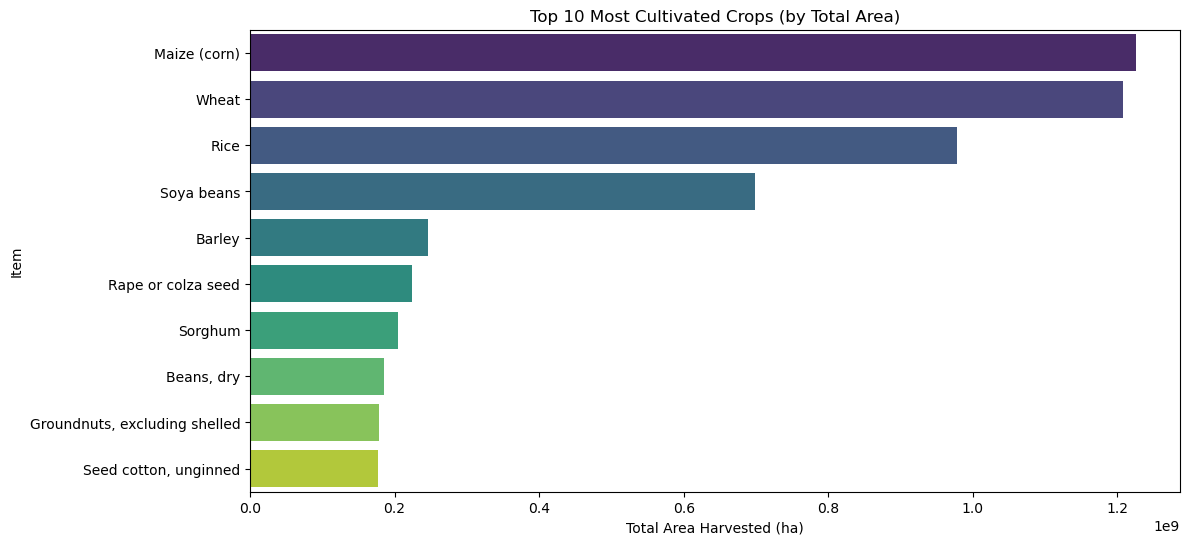

C:\Users\Abhishek PC\AppData\Local\Temp\ipykernel_11740\1202598687.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_regions.values, y=top_regions.index, palette='magma')


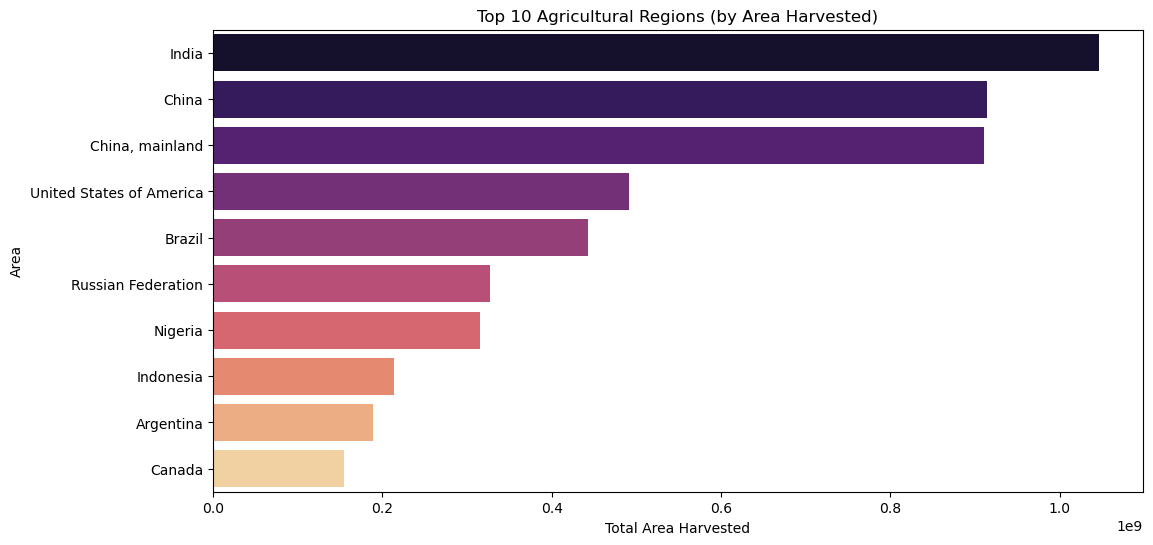

In [7]:
# Crop Distribution Analysis
# Top cultivated crops
plt.figure(figsize=(12, 6))
top_crops = df_pivot.groupby('Item')['Area_Harvested'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_crops.values, y=top_crops.index, palette='viridis')
plt.title("Top 10 Most Cultivated Crops (by Total Area)")
plt.xlabel("Total Area Harvested (ha)")
plt.show()

# Crop distribution by region
top_regions = df_pivot.groupby('Area')['Area_Harvested'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_regions.values, y=top_regions.index, palette='magma')
plt.title("Top 10 Agricultural Regions (by Area Harvested)")
plt.xlabel("Total Area Harvested")
plt.show()


<Figure size 1200x600 with 0 Axes>

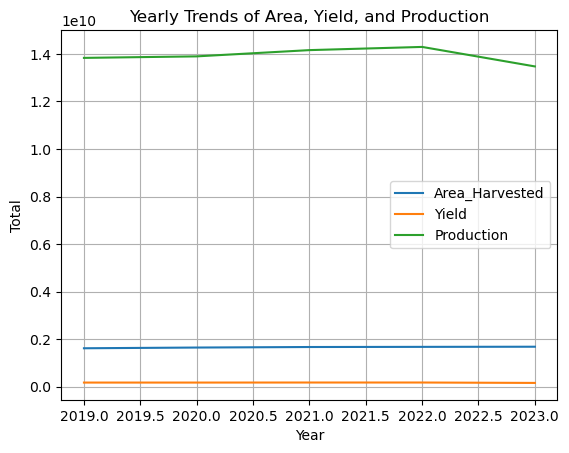

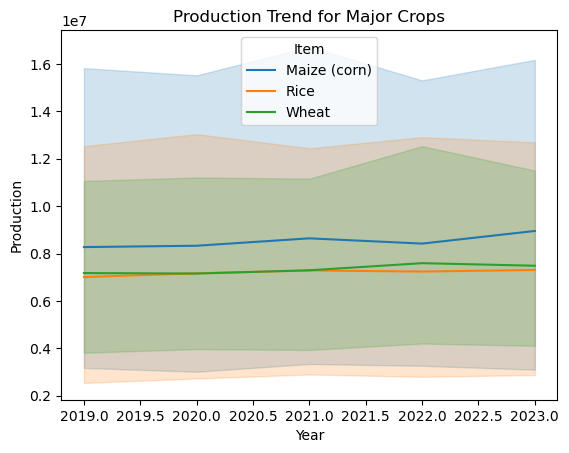

In [8]:
# Temporal Analysis
# Trends over time
yearly = df_pivot.groupby('Year')[['Area_Harvested', 'Yield', 'Production']].sum()

plt.figure(figsize=(12,6))
yearly.plot()
plt.title("Yearly Trends of Area, Yield, and Production")
plt.ylabel("Total")
plt.grid()
plt.show()

# Growth trend per crop
crop_growth = df_pivot[df_pivot['Item'].isin(['Wheat', 'Rice', 'Maize (corn)'])]  # pick major crops
sns.lineplot(data=crop_growth, x='Year', y='Production', hue='Item')
plt.title("Production Trend for Major Crops")
plt.show()


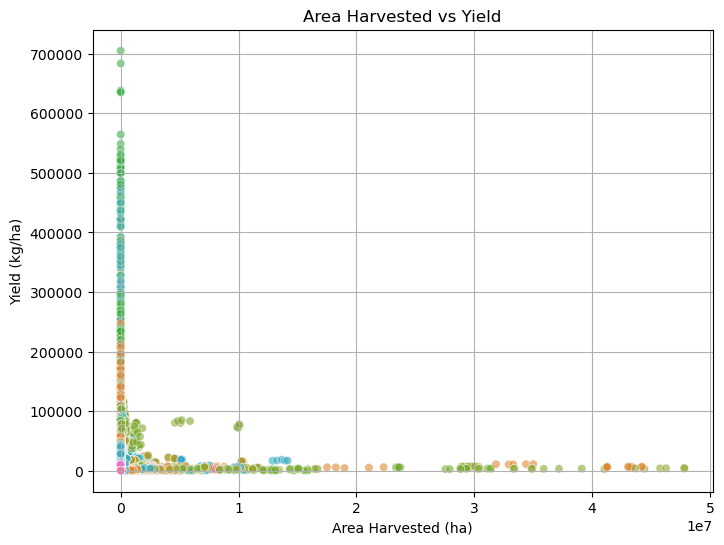

In [9]:
# Environmental Relationship
# Area vs. Yield
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_pivot, x='Area_Harvested', y='Yield', hue='Item', alpha=0.6, legend=False)
plt.title("Area Harvested vs Yield")
plt.xlabel("Area Harvested (ha)")
plt.ylabel("Yield (kg/ha)")
plt.grid()
plt.show()


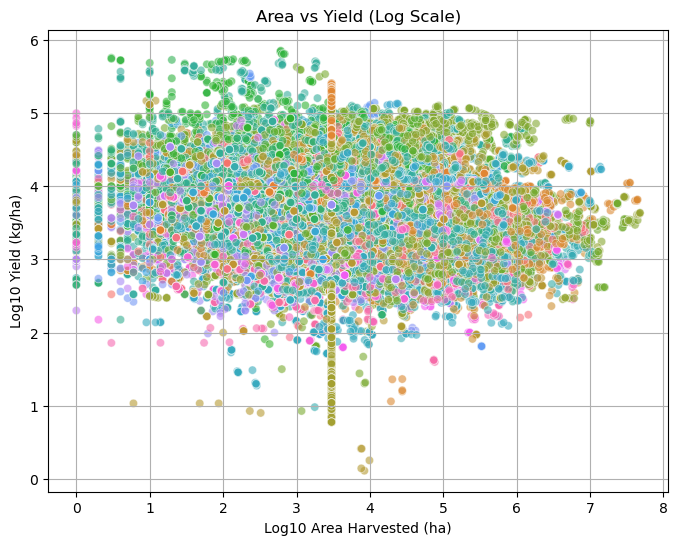

In [10]:
# Environmental Relationship Using Log Sacale As data is Skewed
df_plot = df_pivot[(df_pivot['Area_Harvested'] > 0) & (df_pivot['Yield'] > 0)]

plt.figure(figsize=(8,6))
sns.scatterplot(x=np.log10(df_plot['Area_Harvested']),
                y=np.log10(df_plot['Yield']),
                hue=df_plot['Item'], alpha=0.6, legend=False)
plt.xlabel("Log10 Area Harvested (ha)")
plt.ylabel("Log10 Yield (kg/ha)")
plt.title("Area vs Yield (Log Scale)")
plt.grid()
plt.show()


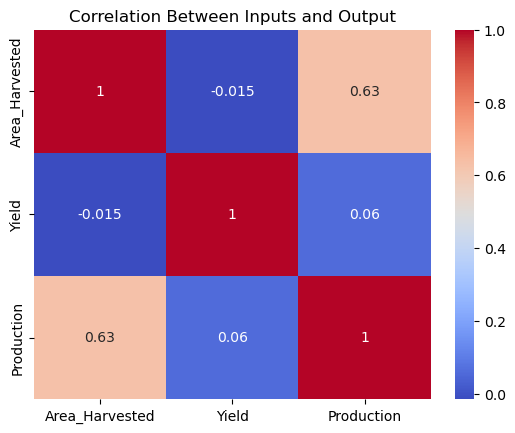

In [11]:
# Input Output Relationship
# Correlation heatmap
sns.heatmap(df_pivot[['Area_Harvested', 'Yield', 'Production']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Inputs and Output")
plt.show()


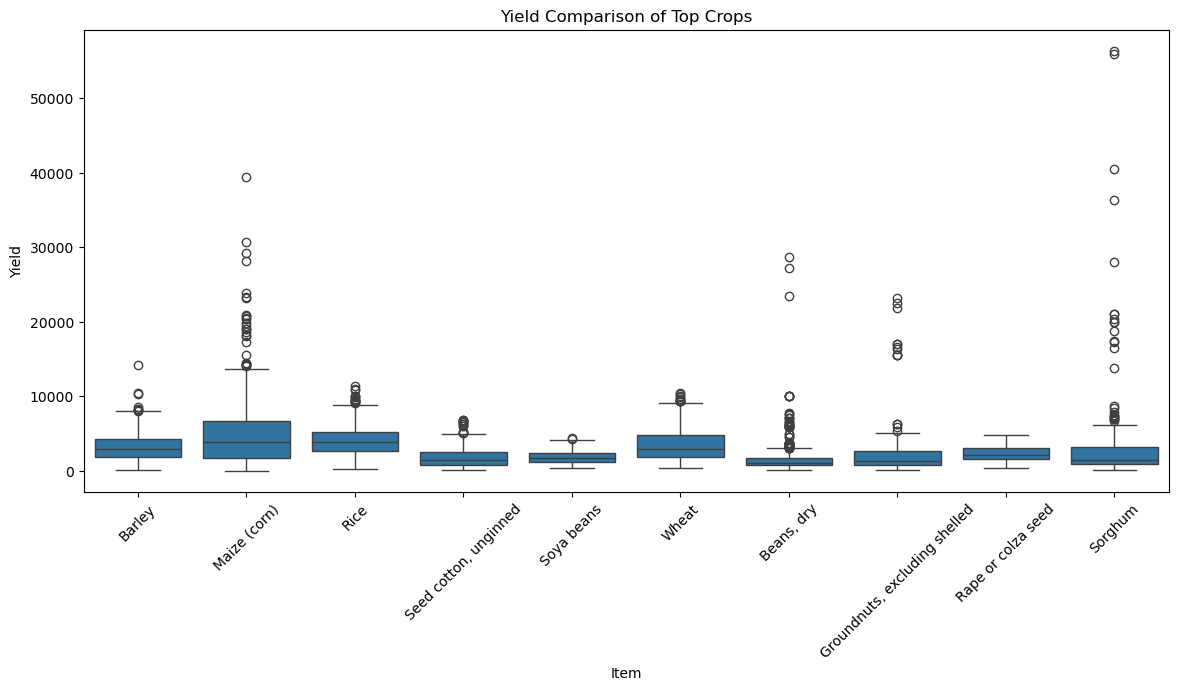

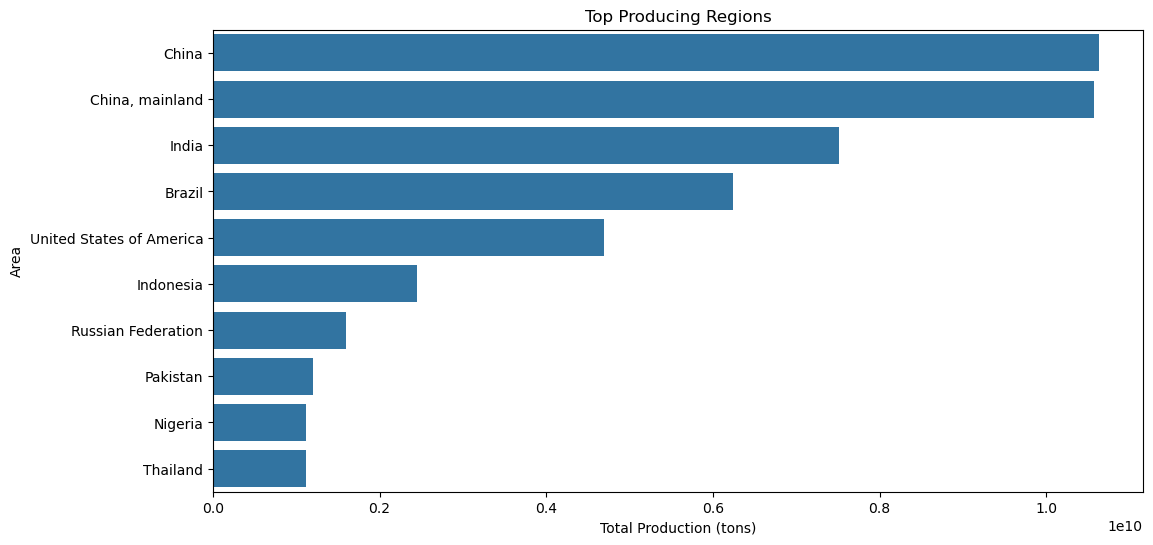

In [12]:
# Comparative Analysis
# Yield comparison by crop
plt.figure(figsize=(14,6))
sns.boxplot(data=df_pivot[df_pivot['Item'].isin(top_crops.index)], x='Item', y='Yield')
plt.title("Yield Comparison of Top Crops")
plt.xticks(rotation=45)
plt.show()

# Production by region
top_area_prod = df_pivot.groupby('Area')['Production'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_area_prod.values, y=top_area_prod.index)
plt.title("Top Producing Regions")
plt.xlabel("Total Production (tons)")
plt.show()


In [13]:
# Productivity Analysis
df_pivot['Productivity'] = df_pivot['Production'] / df_pivot['Area_Harvested']

print("Min productivity:", df_pivot['Productivity'].min())
print("Max productivity:", df_pivot['Productivity'].max())
print("Any NaNs?", df_pivot['Productivity'].isna().sum())

Min productivity: 0.0
Max productivity: inf
Any NaNs? 2652


In [14]:
# # Filter out zero or missing area harvested values
df_pivot_clean = df_pivot[(df_pivot['Area_Harvested'] > 0) & (~df_pivot['Area_Harvested'].isna())].copy()

# Now it's safe to assign
df_pivot_clean['Productivity'] = df_pivot_clean['Production'] / df_pivot_clean['Area_Harvested']

print("Min productivity:", df_pivot_clean['Productivity'].min())
print("Max productivity:", df_pivot_clean['Productivity'].max())
print("Any NaNs?", df_pivot_clean['Productivity'].isna().sum())

Min productivity: 0.0
Max productivity: 42368.38
Any NaNs? 0


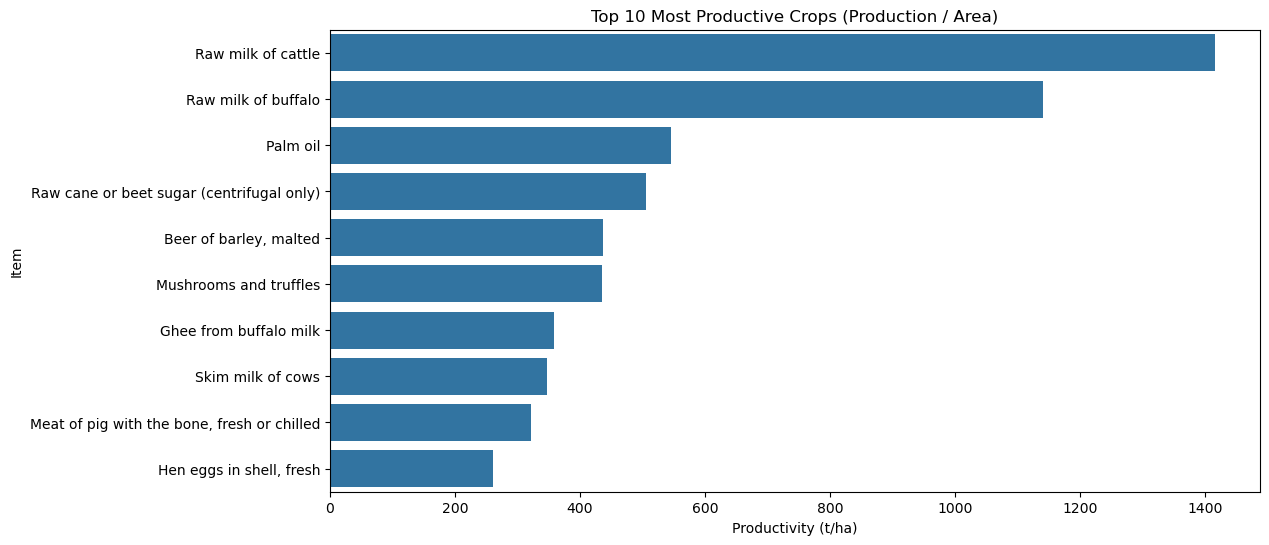

In [15]:
# Productivity Analysis On Cleaned Data
df_pivot_clean['Productivity'] = df_pivot_clean['Production'] / df_pivot_clean['Area_Harvested']

# Productivity by crop
prod_eff = df_pivot_clean.groupby('Item')['Productivity'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=prod_eff.values, y=prod_eff.index)
plt.title("Top 10 Most Productive Crops (Production / Area)")
plt.xlabel("Productivity (t/ha)")
plt.show()


In [16]:
# Yield Variation Accross Crops
# Standard deviation of yield across crops
yield_stats_crop = df_pivot.groupby('Item')['Yield'].agg(['mean', 'std']).sort_values(by='mean', ascending=False)

# Top 10 efficient (high mean) and consistent (low std) crops
yield_stats_crop['cv'] = yield_stats_crop['std'] / yield_stats_crop['mean']  # Coefficient of Variation

print("Top 10 High-Yield Crops with Low Variation (Efficient Crops):")
yield_stats_crop.sort_values(by=['mean', 'cv'], ascending=[False, True]).head(10)


Top 10 High-Yield Crops with Low Variation (Efficient Crops):


,mean,std,cv
Item,,,
"Hen eggs in shell, fresh",89221.056734,56152.834503,0.629368
Cucumbers and gherkins,60643.414370,106939.409068,1.763413
Tomatoes,59554.853542,90083.953206,1.512622
Sugar cane,58178.661795,26923.807319,0.462778
Sugar beet,49402.453438,22959.285067,0.464740
"Eggs from other birds in shell, fresh, n.e.c.",45784.775000,23690.708900,0.517436
Eggplants (aubergines),34499.551297,69112.715663,2.003293
Raw milk of cattle,30581.449198,30788.430986,1.006768
Watermelons,29894.563881,34440.177642,1.152055


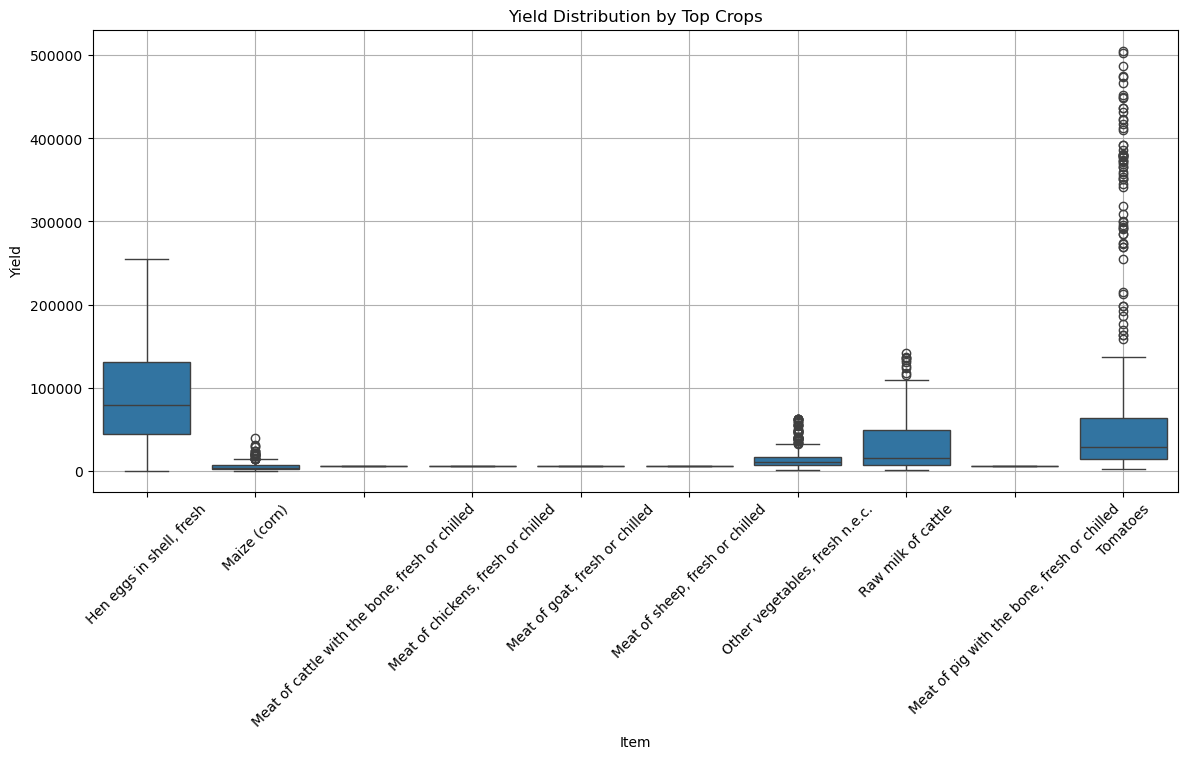

In [17]:
# Yield BoxPlot By Crop
top_items = df_pivot['Item'].value_counts().head(10).index
plt.figure(figsize=(14,6))
sns.boxplot(data=df_pivot[df_pivot['Item'].isin(top_items)], x='Item', y='Yield')
plt.title("Yield Distribution by Top Crops")
plt.xticks(rotation=45)
plt.grid()
plt.show()


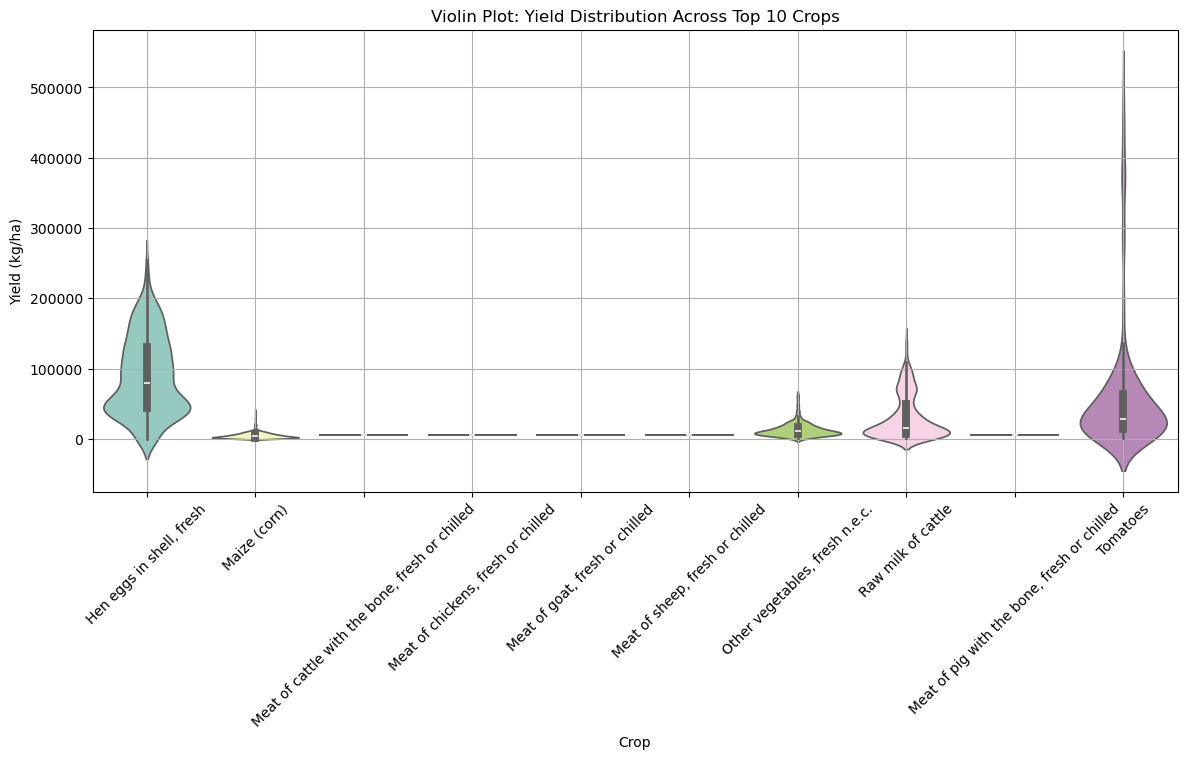

In [18]:
# Select top 10 crops by record count for visual clarity
top_items = df_pivot['Item'].value_counts().head(10).index
plt.figure(figsize=(14,6))

sns.violinplot(
    data=df_pivot[df_pivot['Item'].isin(top_items)],
    x='Item',
    y='Yield',
    hue='Item',             # Add hue to explicitly assign palette
    palette="Set3",
    dodge=False,            # Prevents multiple violins per item
    legend=False            # Avoids duplicated legend
)
plt.title("Violin Plot: Yield Distribution Across Top 10 Crops")
plt.xlabel("Crop")
plt.ylabel("Yield (kg/ha)")
plt.xticks(rotation=45)
plt.grid()
plt.show()


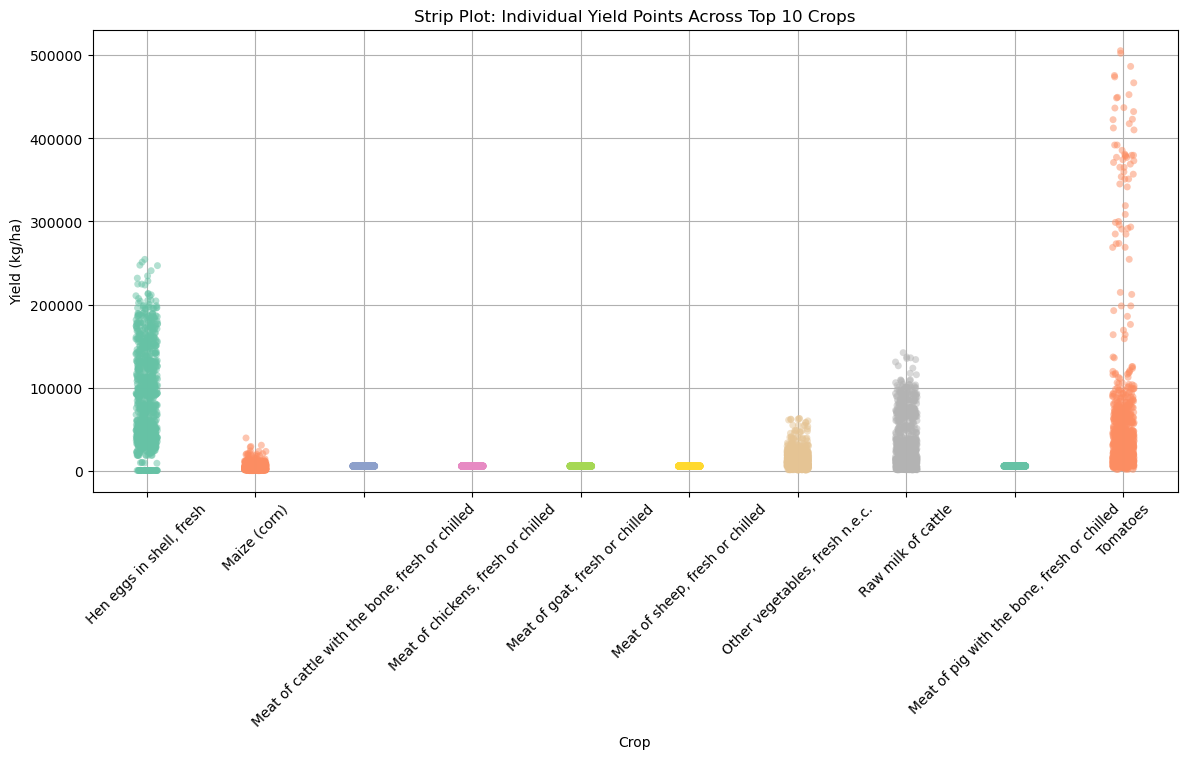

In [19]:
plt.figure(figsize=(14,6))

sns.stripplot(
    data=df_pivot[df_pivot['Item'].isin(top_items)],
    x='Item',
    y='Yield',
    hue='Item',             # Explicit hue assignment
    palette="Set2",
    dodge=False,            # Prevents side-by-side jittered points
    jitter=True,
    alpha=0.5,
    legend=False            # Avoid extra color legend
)
plt.title("Strip Plot: Individual Yield Points Across Top 10 Crops")
plt.xlabel("Crop")
plt.ylabel("Yield (kg/ha)")
plt.xticks(rotation=45)
plt.grid()
plt.show()



In [20]:
# Yield Variation Accross Rgions
# Stats per region
yield_stats_area = df_pivot.groupby('Area')['Yield'].agg(['mean', 'std'])
yield_stats_area['cv'] = yield_stats_area['std'] / yield_stats_area['mean']

print("Top Efficient Regions by Yield:")
yield_stats_area.sort_values(by=['mean', 'cv'], ascending=[False, True]).head(10)


Top Efficient Regions by Yield:


,mean,std,cv
Area,,,
Iceland,35636.857576,100454.240965,2.818830
Guyana,35070.220475,57603.645531,1.642523
Netherlands (Kingdom of the),32851.321414,98716.597659,3.004951
Belgium,27939.247006,79728.064387,2.853623
Oman,27400.547902,71483.632498,2.608840
United Kingdom of Great Britain and Northern Ireland,25073.122115,72637.457172,2.897025
Kuwait,23675.613980,27401.538168,1.157374
Bahrain,23380.204234,35195.883809,1.505371
Austria,20793.269147,40764.562511,1.960469


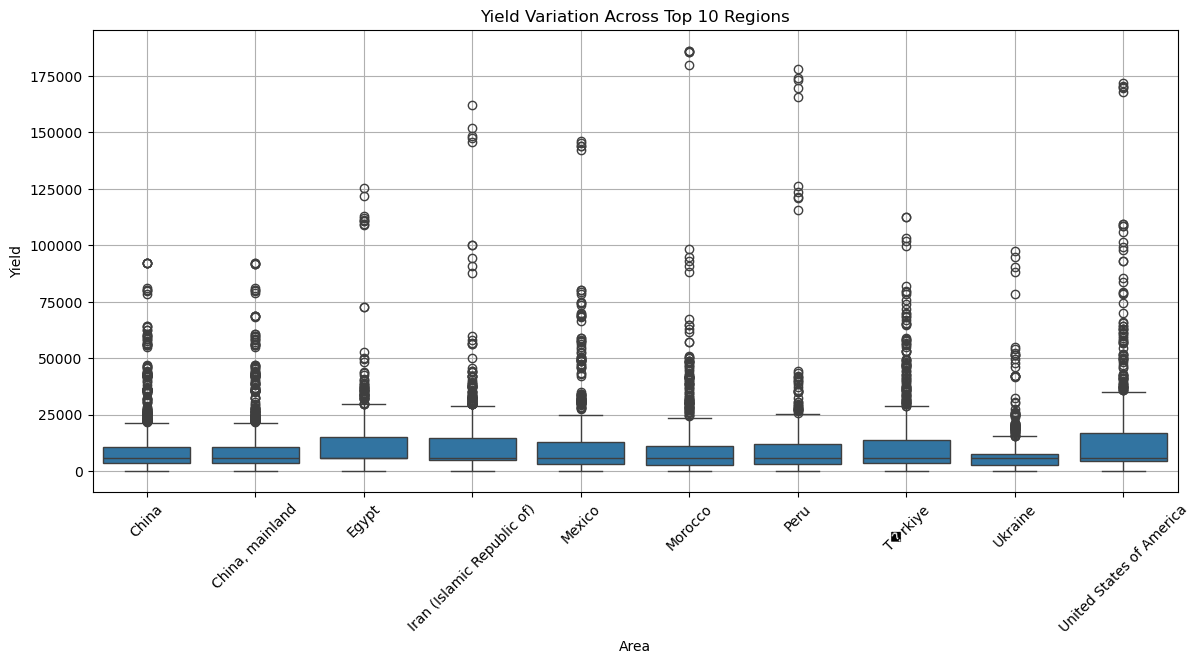

In [21]:
# Select top 10 regions by record count
top_areas = df_pivot['Area'].value_counts().head(10).index
plt.figure(figsize=(14,6))
sns.boxplot(data=df_pivot[df_pivot['Area'].isin(top_areas)], x='Area', y='Yield')
plt.title("Yield Variation Across Top 10 Regions")
plt.xticks(rotation=45)
plt.grid()
plt.show()


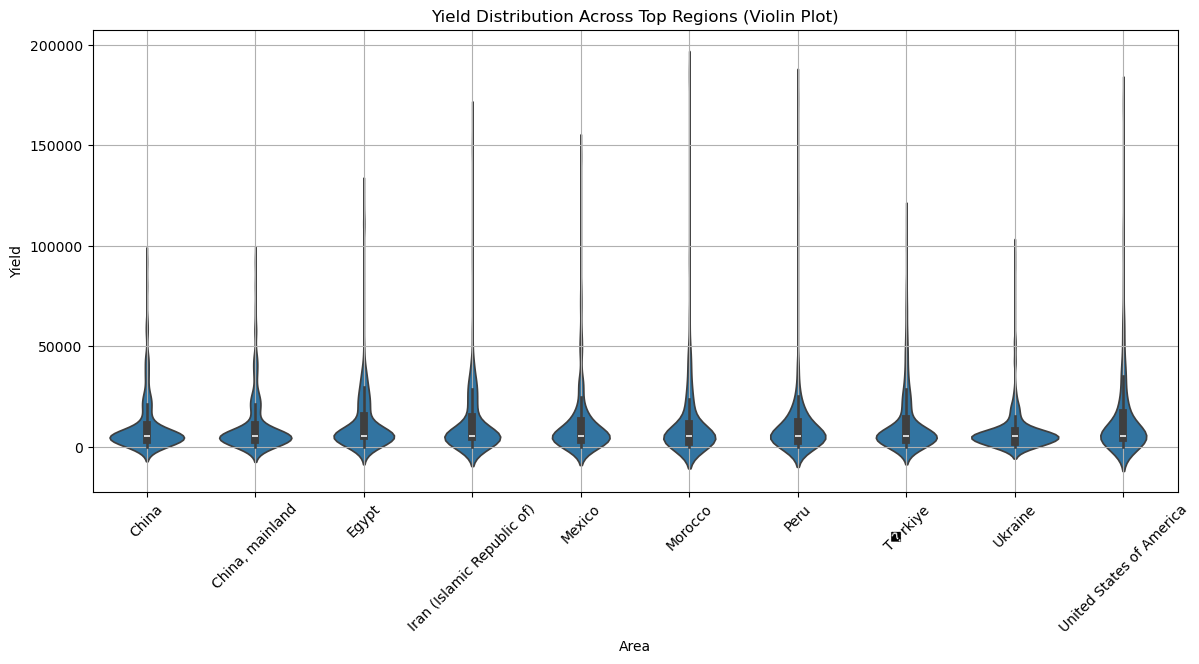

In [22]:
plt.figure(figsize=(14,6))
sns.violinplot(data=df_pivot[df_pivot['Area'].isin(top_areas)], x='Area', y='Yield', inner="box")
plt.title("Yield Distribution Across Top Regions (Violin Plot)")
plt.xticks(rotation=45)
plt.grid()
plt.show()


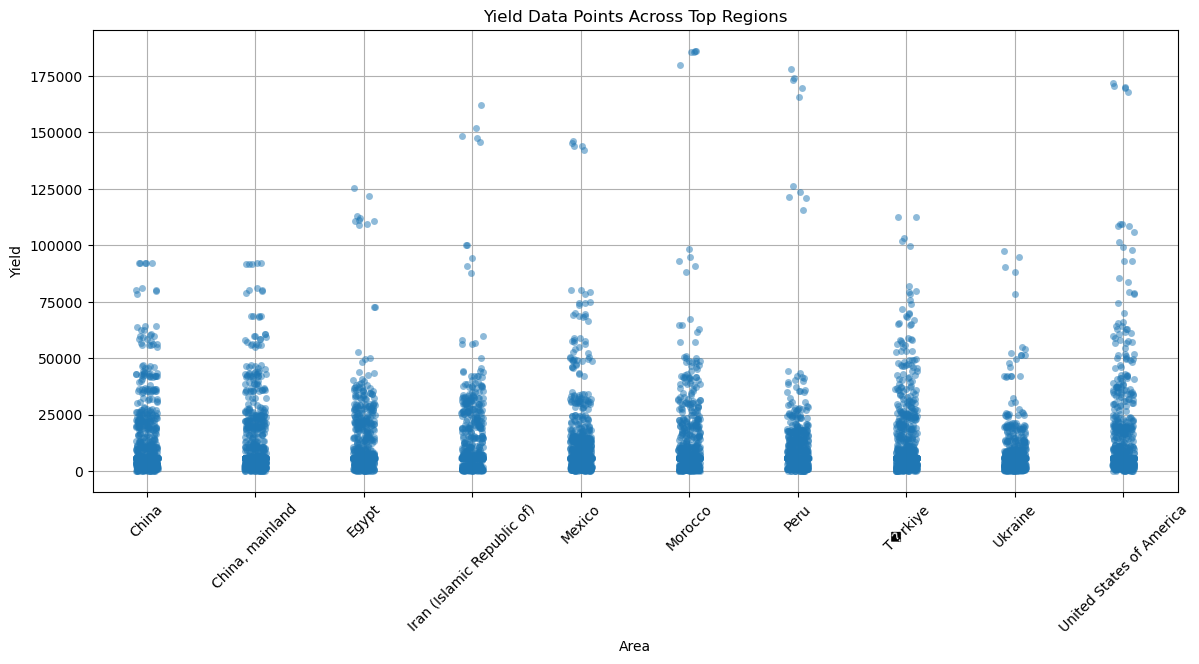

In [23]:
plt.figure(figsize=(14,6))
sns.stripplot(data=df_pivot[df_pivot['Area'].isin(top_areas)], x='Area', y='Yield', alpha=0.5, jitter=True)
plt.title("Yield Data Points Across Top Regions")
plt.xticks(rotation=45)
plt.grid()
plt.show()


In [24]:
# Z-score outlier detection
from scipy.stats import zscore

z_scores = df_pivot[['Area_Harvested', 'Yield', 'Production']].apply(zscore)
outliers = df_pivot[(np.abs(z_scores) > 3).any(axis=1)]

print(f"Number of outlier records: {len(outliers)}")
outliers[['Area', 'Item', 'Year', 'Area_Harvested', 'Yield', 'Production']]


Number of outlier records: 1755


,Area,Item,Year,Area_Harvested,Yield,Production
459,Albania,"Hen eggs in shell, fresh",2019,3000.0,108975.0,54527.15
460,Albania,"Hen eggs in shell, fresh",2020,3000.0,108349.0,54244.13
461,Albania,"Hen eggs in shell, fresh",2021,3000.0,107453.0,56628.00
462,Albania,"Hen eggs in shell, fresh",2022,3000.0,96213.0,48918.00
463,Albania,"Hen eggs in shell, fresh",2023,3000.0,87623.0,42558.66
...,...,...,...,...,...,...
81395,Zambia,Sugar cane,2019,45100.0,103813.0,4682000.00
81396,Zambia,Sugar cane,2020,43172.0,103845.8,4483188.17
81397,Zambia,Sugar cane,2021,40947.0,103792.4,4250000.00
81398,Zambia,Sugar cane,2022,43850.0,103762.6,4550000.00


In [25]:
# Predicting Production
# Label encode categorical features
le_area = LabelEncoder()
le_item = LabelEncoder()

df_pivot['Area_encoded'] = le_area.fit_transform(df_pivot['Area'])
df_pivot['Item_encoded'] = le_item.fit_transform(df_pivot['Item'])

# Feature and target
X = df_pivot[['Area_encoded', 'Item_encoded', 'Year', 'Area_Harvested', 'Yield']]
y = df_pivot['Production']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results[name] = {
        "R2 Score": r2_score(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred)
    }

pd.DataFrame(results).T


,R2 Score,MSE,MAE
Linear Regression,0.373961,8.653483e+13,972037.080579
Random Forest,0.989300,1.479057e+12,86918.040947
Gradient Boosting,0.962664,5.160823e+12,407393.048666
XGBoost,0.986285,1.895814e+12,242261.755999


In [26]:
# Show comparison to Choose the model with the highest R² and lowest MSE for deployment.
results_df = pd.DataFrame(results).T.sort_values(by="R2 Score", ascending=False)
print(results_df)


                   R2 Score           MSE            MAE
Random Forest      0.989300  1.479057e+12   86918.040947
XGBoost            0.986285  1.895814e+12  242261.755999
Gradient Boosting  0.962664  5.160823e+12  407393.048666
Linear Regression  0.373961  8.653483e+13  972037.080579


In [27]:
# Save the best model with joblib for our Streamlit app
import joblib
joblib.dump(models['Random Forest'], 'models/model_rf.pkl')
joblib.dump(le_area, 'models/le_area.pkl')
joblib.dump(le_item, 'models/le_item.pkl')


['models/le_item.pkl']